<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Spectre_2D_nebuleuses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectre 2D – longueur d'onde × arcsec
Visualisation d'un spectre 2D issu d'un traitement ISIS (Alpy 600).


## 1 · Installation des dépendances


In [14]:
!pip install astropy -q

## 2 · Imports


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tifffile
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d
from google.colab import files
from astropy.io import fits

## 3 · Configuration — **éditer cette cellule avant d'exécuter**


In [16]:
# ============================================================
# CONFIGURATION PRINCIPALE
# ============================================================

# -- Titre de la figure (affiché sur l'axe Y) --
TITRE = "Spectre 2D de NGC 2024, nébuleuse de la Flamme"

# -- Échantillonnage spatial --
# arcsec/pixel = (taille_pixel_µm / focale_mm) × 206265
ARCSEC_PAR_PIXEL = 1.478

# -- Plage spectrale affichée (Å) --
WL_MIN = 3800.0
WL_MAX = 7500.0

# -- Plage spatiale affichée (arcsec) --
# None = détection automatique + marges (cellule 7b)
Y_MIN_ARCSEC = None
Y_MAX_ARCSEC = None

# -- Seuil de détection de la fente (fraction du max du profil net) --
SEUIL_FENTE = 0.15

# -- Marge affichée au-delà des extrémités de la fente (arcsec) --
MARGE_ARCSEC = 50.0

# -- Nom du fichier de sortie --
OUTPUT_PNG = "spectre_2D.png"

print("Configuration chargée.")


Configuration chargée.


## 4 · Polynôme de calibration ISIS
Copier-coller les coefficients affichés par ISIS après calibration.
Forme : λ(x) = A0 + A1·x + A2·x² + A3·x³ + A4·x⁴  (x = indice pixel 0-based)


In [17]:
A0 =  2874.05
A1 =  3.3523613
A2 =  0.000461822
A3 = -3.856712e-07
A4 =  7.309561e-11

def pixel_to_wavelength(x):
    """Polynôme de calibration ISIS (ordre 4)."""
    return A0 + A1*x + A2*x**2 + A3*x**3 + A4*x**4

for xi in [0, 500, 1000, 1500]:
    print(f"  pixel {xi:5d}  →  {pixel_to_wavelength(xi):.2f} Å")


  pixel     0  →  2874.05 Å
  pixel   500  →  4622.05 Å
  pixel  1000  →  6375.66 Å
  pixel  1500  →  8010.10 Å


## 5 · Sélection des raies à annoter
Mettre `True` pour afficher une raie, `False` pour la masquer.


In [32]:
# (nom_affiché, λ_repos_Å, afficher)
RAIES = [
    # Hydrogène – Balmer
    ("Hβ",          4861.33, True ),
    ("Hα",          6562.80, True ),
    ("Hγ",          4340.47, False),
    ("Hδ",          4101.74, False),
    # Oxygène doublement ionisé
    ("[OIII]",      4958.91, False),
    ("[OIII]",      5006.84, False),
    # Azote ionisé
    ("[NII]",       6548.05, True ),
    ("[NII]",       6583.45, True ),
    # Soufre ionisé
    ("[SII]",       6716.44, False),
    ("[SII]",       6730.82, False),
    # Oxygène neutre – PDR
    ("[OI] PDR",    6300.30, False ),
    ("[OI] PDR",    6363.78, False),
    # Hélium ionisé
    ("HeI",         5875.62, True ),
    ("HeI",         6678.15, False),
    # Sodium atmosphérique
    ("NaI D",       5889.95, True ),
    ("NaI D",       5895.92, True ),
    # Airglow
    ("[OI] airglow",     5577.34, True ),
    ("[OI] airglow",     6300.30, True ),
]

raies_actives = [(nom, lam) for nom, lam, actif in RAIES if actif]
print(f"{len(raies_actives)} raie(s) activée(s) :")
for nom, lam in raies_actives:
    print(f"  {nom:12s}  {lam:.2f} Å")


9 raie(s) activée(s) :
  Hβ            4861.33 Å
  Hα            6562.80 Å
  [NII]         6548.05 Å
  [NII]         6583.45 Å
  HeI           5875.62 Å
  NaI D         5889.95 Å
  NaI D         5895.92 Å
  [OI] airglow  5577.34 Å
  [OI] airglow  6300.30 Å


## 6 · Chargement du fichier FITS (issu d'ISIS)

In [7]:
print("Sélectionner le fichier FITS 2D issu d'ISIS :")
uploaded  = files.upload()
fits_file = list(uploaded.keys())[0]

with fits.open(fits_file) as hdul:
    image_raw = hdul[0].data.astype(float)   # int32 ISIS -> float
    header    = hdul[0].header

# Supprimer une éventuelle dimension superflue (1, ny, nx)
if image_raw.ndim == 3 and image_raw.shape[0] == 1:
    image_raw = image_raw[0]

# Conserver l'image brute intacte : source de vérité, jamais modifiée
image_brute = image_raw.copy()

ny, nx = image_raw.shape
print(f"Fichier    : {fits_file}")
print(f"BITPIX     : {header.get('BITPIX')}   (ISIS : entiers 32 bits signés)")
print(f"Dimensions : {nx} px spectraux × {ny} px spatiaux")
print(f"ADU min / max : {image_raw.min():.0f} / {image_raw.max():.0f}"
      f"   (valeurs négatives = fond de ciel soustrait par ISIS)")

Sélectionner le fichier FITS 2D issu d'ISIS :


Saving _Flamme.fits to _Flamme.fits
Fichier    : _Flamme.fits
BITPIX     : 32   (ISIS : entiers 32 bits signés)
Dimensions : 1391 px spectraux × 1039 px spatiaux
ADU min / max : -227 / 9530   (valeurs négatives = fond de ciel soustrait par ISIS)


## 6b · Prétraitement de l'histogramme (normalisation + asinh)

Reproduit le traitement PixInsight :
1. **Normalisation min–max** → ramène l'image dans `[0, 1]` :
   `($T − min) / (max − min)`
2. **Étirement asinh** avec soustraction du fond → révèle le continuum faible sans saturer les raies :
   `asinh(max($T − FOND, 0) × K) / asinh(K)`

**Deux paramètres à ajuster :**

| Paramètre | Rôle | Effet |
|-----------|------|-------|
| `K` (=100) | Force de l'étirement asinh | ↑ K → continuum faible plus visible, raies plus comprimées. Essayer 20–150. |
| `FOND` (=0.02) | Niveau de fond soustrait (en normalisé, après min–max) | ↑ FOND → fond plus sombre. Augmenter si le fond est trop clair, diminuer s'il est écrasé/noir. |

Repère : `FOND = 0.02` amène typiquement le fond vers ~30/256 en visualisation. `max(... , 0)` empêche toute valeur négative. En figeant `K` et `FOND`, le traitement reste **identique et comparable** d'un spectre de nébuleuse à l'autre.

> **Note FITS/ISIS :** l'image contient des valeurs négatives (fond soustrait). La normalisation min–max les ramène proprement dans `[0, 1]` (le minimum réel devient 0), exactement comme dans PixInsight.

Normalisation min–max : [-227, 9530]  ->  [0, 1]
Étirement asinh       : K = 100, FOND = 0.02
Après traitement      : min = 0.0000  médiane = 0.0804  max = 0.9962


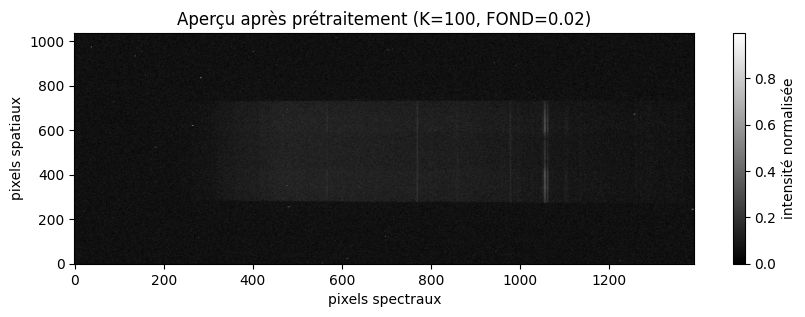

In [33]:
# ============================================================
# PRÉTRAITEMENT HISTOGRAMME — à ajuster
# ============================================================
K    = 100     # force de l'étirement asinh (essayer 20 à 150)
FOND = 0.02    # niveau de fond soustrait, en normalisé [0,1] (↑ = fond plus sombre)
# ============================================================

# IMPORTANT : on repart TOUJOURS de l'image brute (image_brute),
# jamais de image_raw — sinon l'asinh s'empilerait sur lui-même
# à chaque réexécution de cette cellule (image aplatie, profil vide,
# IndexError plus loin). Ce cadrage rend la cellule ré-exécutable à volonté.

# 1) Normalisation min–max  ->  [0, 1]
img_min = image_brute.min()
img_max = image_brute.max()
image_norm = (image_brute - img_min) / (img_max - img_min)

# 2) Étirement asinh avec soustraction du fond
image_stretch = np.arcsinh(np.maximum(image_norm - FOND, 0.0) * K) / np.arcsinh(K)

# L'image traitée alimente la suite du notebook
image_raw = image_stretch

print(f"Normalisation min–max : [{img_min:.0f}, {img_max:.0f}]  ->  [0, 1]")
print(f"Étirement asinh       : K = {K}, FOND = {FOND}")
print(f"Après traitement      : min = {image_raw.min():.4f}  "
      f"médiane = {np.median(image_raw):.4f}  max = {image_raw.max():.4f}")

# Aperçu rapide
plt.figure(figsize=(10, 3))
plt.imshow(image_raw, origin='lower', cmap='gray', aspect='auto')
plt.title(f"Aperçu après prétraitement (K={K}, FOND={FOND})")
plt.xlabel("pixels spectraux"); plt.ylabel("pixels spatiaux")
plt.colorbar(label="intensité normalisée"); plt.show()

## 7 · Rééchantillonnage spectral et axes


In [34]:
pixels      = np.arange(nx)
wavelengths = pixel_to_wavelength(pixels)

# Grille λ linéaire cible
wl_lin = np.linspace(wavelengths[0], wavelengths[-1], nx)
dl     = wl_lin[1] - wl_lin[0]

# Rééchantillonnage X ligne par ligne
image_resampled = np.zeros_like(image_raw)
for row in range(ny):
    f = interp1d(wavelengths, image_raw[row, :],
                 kind='linear', bounds_error=False, fill_value=0)
    image_resampled[row, :] = f(wl_lin)

# Axe Y en arcsec — origine provisoire à 0
arcsec = np.arange(ny) * ARCSEC_PAR_PIXEL

print(f"Plage spectrale : {wl_lin[0]:.1f} – {wl_lin[-1]:.1f} Å  (pas {dl:.3f} Å/pixel)")
print(f"Plage spatiale  : {arcsec[0]:.1f} – {arcsec[-1]:.1f} arcsec")


Plage spectrale : 2874.1 – 7663.2 Å  (pas 3.445 Å/pixel)
Plage spatiale  : 0.0 – 1534.2 arcsec


## 7b · Détection automatique des extrémités de la fente


Fond estimé    : 0 ADU
Profil net max : 0 ADU  seuil (15%) : 0
Fente détectée : pixels 278 – 735
Longueur utile : 675.4 arcsec  (0 → 675.4)
Affichage      : -50 → 725.4 arcsec


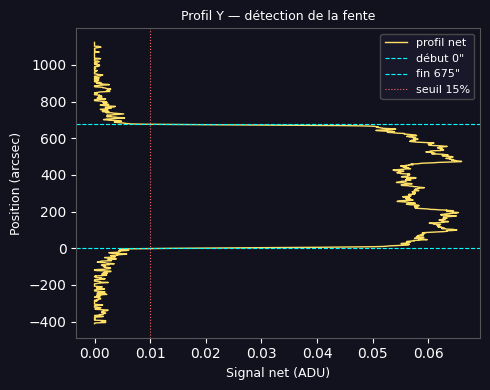

Si la détection est incorrecte, ajuster SEUIL_FENTE dans la cellule 3 et réexécuter.


In [35]:
# Profil médian en Y sur le quart central de l'axe X (évite les raies brillantes)
x_lo = nx // 4
x_hi = 3 * nx // 4
profil_y     = np.median(image_resampled[:, x_lo:x_hi], axis=1)
profil_lisse = uniform_filter1d(profil_y, size=5)

# Soustraction du fond estimé sur les bords (hors fente)
n_bord       = max(3, ny // 20)
fond         = np.median(np.concatenate([profil_lisse[:n_bord], profil_lisse[-n_bord:]]))
profil_net   = np.clip(profil_lisse - fond, 0, None)

# Détection par seuil sur le profil net
seuil         = SEUIL_FENTE * profil_net.max()
indices_fente = np.where(profil_net > seuil)[0]

# --- Garde-fou : aucun pixel au-dessus du seuil ---
if indices_fente.size == 0:
    raise ValueError(
        "Aucune fente détectée : le profil net ne dépasse jamais le seuil.\n"
        f"  - profil net max = {profil_net.max():.4g} (seuil = {seuil:.4g})\n"
        "Causes probables :\n"
        "  1) FOND trop élevé dans la cellule 6b -> le signal a été écrasé.\n"
        f"     Baisser FOND (essayer 0.01–0.02) puis réexécuter 6b et cette cellule.\n"
        "  2) SEUIL_FENTE trop haut dans la cellule 3 -> l'abaisser (ex. 0.05–0.10).\n"
        "  3) Spectre trop faible ou fente hors de la zone analysée."
    )

y_px_min      = indices_fente[0]
y_px_max      = indices_fente[-1]

# Recalage : le début de la fente = 0 arcsec
arcsec      = arcsec - arcsec[y_px_min]
y_fente_min = 0.0
y_fente_max = arcsec[y_px_max]

# Plage d'affichage avec marges
y_lo_display = -MARGE_ARCSEC
y_hi_display =  y_fente_max + MARGE_ARCSEC

print(f"Fond estimé    : {fond:.0f} ADU")
print(f"Profil net max : {profil_net.max():.0f} ADU  seuil ({SEUIL_FENTE*100:.0f}%) : {seuil:.0f}")
print(f"Fente détectée : pixels {y_px_min} – {y_px_max}")
print(f"Longueur utile : {y_fente_max:.1f} arcsec  (0 → {y_fente_max:.1f})")
print(f"Affichage      : {y_lo_display:.0f} → {y_hi_display:.1f} arcsec")

# Graphe de vérification
fig_p, ax_p = plt.subplots(figsize=(5, 4))
fig_p.patch.set_facecolor('#12121f')
ax_p.set_facecolor('#12121f')
ax_p.plot(profil_net, arcsec, color='#ffe066', lw=1, label='profil net')
ax_p.axhline(y_fente_min, color='cyan', lw=0.8, linestyle='--', label=f'début {y_fente_min:.0f}"')
ax_p.axhline(y_fente_max, color='cyan', lw=0.8, linestyle='--', label=f'fin {y_fente_max:.0f}"')
ax_p.axvline(seuil, color='#ff6666', lw=0.8, linestyle=':', label=f'seuil {SEUIL_FENTE*100:.0f}%')
ax_p.set_xlabel("Signal net (ADU)", fontsize=9, color='white')
ax_p.set_ylabel("Position (arcsec)", fontsize=9, color='white')
ax_p.set_title("Profil Y — détection de la fente", fontsize=9, color='white')
ax_p.tick_params(colors='white')
ax_p.legend(fontsize=8, labelcolor='white', facecolor='#1a1a2e', edgecolor='#555555')
for spine in ax_p.spines.values():
    spine.set_edgecolor('#555555')
plt.tight_layout()
plt.show()
print("Si la détection est incorrecte, ajuster SEUIL_FENTE dans la cellule 3 et réexécuter.")


## 7c · Colorisation physique λ → RGB


In [36]:
def wavelength_to_rgb(lam):
    """
    Convertit une longueur d'onde (Å) en couleur RGB [0,1].
    Formule de Dan Bruton étendue, transition NIR corrigée :
      UV proche  3600–3800 Å → violet extrapolé
      Visible    3800–7000 Å → spectre physique
      NIR proche 7000–7800 Å → rouge décroissant en continu (plus de rebond)
    """
    wl = lam / 10.0   # Å → nm

    # UV proche
    if 360 <= wl < 380:
        t = (wl - 360) / 20
        return (0.44 * t * (0.3 + 0.4*t), 0.0, (0.5 + 0.5*t) * (0.3 + 0.4*t))

    # Hors domaine
    if wl < 360 or wl > 780:
        return (0.0, 0.0, 0.0)

    # Teinte de base
    if   380 <= wl < 440: R, G, B = -(wl-440)/60,  0.0,          1.0
    elif 440 <= wl < 490: R, G, B =  0.0,           (wl-440)/50,  1.0
    elif 490 <= wl < 510: R, G, B =  0.0,           1.0,         -(wl-510)/20
    elif 510 <= wl < 580: R, G, B =  (wl-510)/70,   1.0,          0.0
    elif 580 <= wl < 645: R, G, B =  1.0,          -(wl-645)/65,  0.0
    else:                 R, G, B =  1.0,           0.0,          0.0   # ≥ 645 nm : rouge pur

    # Facteur d'intensité — CONTINU et MONOTONE sur tout le domaine
    # (plateau à 1.0 dans le visible, descente NIR douce, sans discontinuité à 700 nm)
    if   380 <= wl < 420: factor = 0.3 + 0.7*(wl-380)/40    # montée UV
    elif 420 <= wl < 700: factor = 1.0                       # plateau visible
    else:                 factor = 0.3 + 0.7*(780-wl)/80     # descente NIR 700→780 nm

    return (R*factor, G*factor, B*factor)

# Table de couleurs : une entrée par colonne X
color_table = np.array([wavelength_to_rgb(w) for w in wl_lin])  # (nx, 3)

# Normalisation par le maximum absolu — contrastes Prism/PixInsight préservés
L_max = image_resampled.max()
L     = np.clip(image_resampled / (L_max + 1e-12), 0, 1)

# Image RGB finale
image_rgb = color_table[np.newaxis, :, :] * L[:, :, np.newaxis]
image_rgb = np.clip(image_rgb, 0, 1)

print(f"Image RGB : {image_rgb.shape}  —  normalisation sur max absolu = {L_max:.0f} ADU")


Image RGB : (1039, 1391, 3)  —  normalisation sur max absolu = 1 ADU


## 8 · Affichage


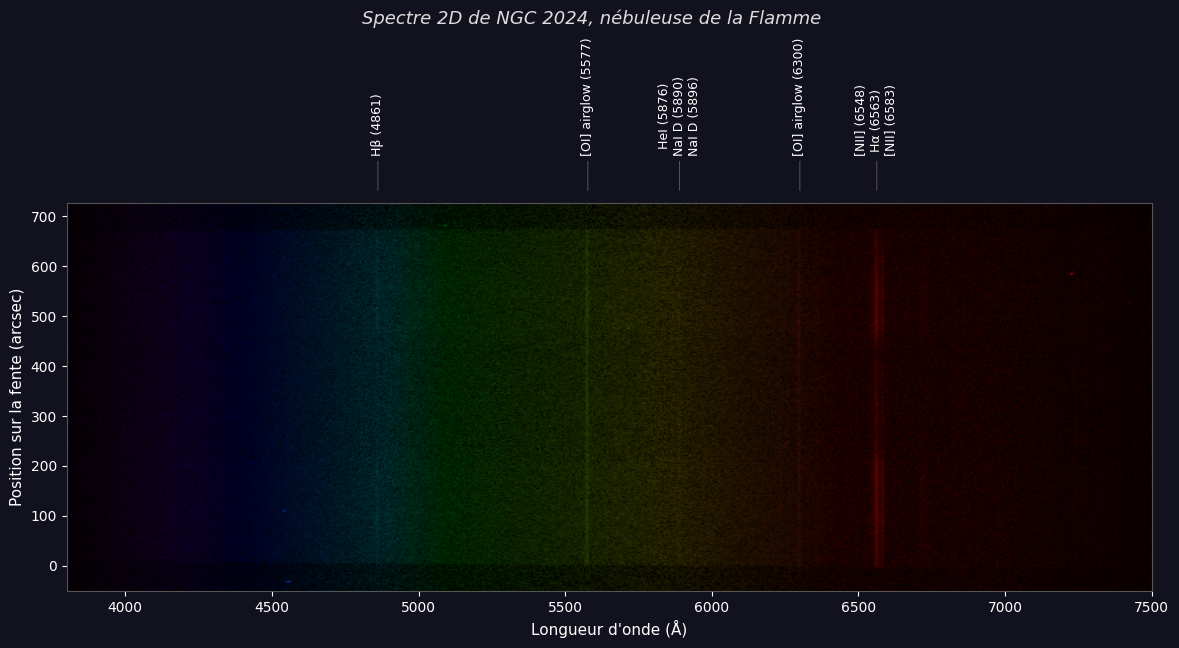

In [37]:
# ============================================================
# FIGURE : bandeau d'annotations + carte λ × arcsec
# ============================================================

extent = [wl_lin[0], wl_lin[-1], arcsec[0], arcsec[-1]]

wl_lo = WL_MIN
wl_hi = WL_MAX
y_lo  = y_lo_display if Y_MIN_ARCSEC is None else Y_MIN_ARCSEC
y_hi  = y_hi_display if Y_MAX_ARCSEC is None else Y_MAX_ARCSEC

raies_visibles = sorted(
    [(nom, lam) for nom, lam in raies_actives if wl_lo <= lam <= wl_hi],
    key=lambda r: r[1]
)

# ---- Regroupement des raies proches en clusters ----
CLUSTER_AA = 120

clusters = []
i = 0
while i < len(raies_visibles):
    groupe = [raies_visibles[i]]
    while i + 1 < len(raies_visibles) and raies_visibles[i+1][1] - raies_visibles[i][1] < CLUSTER_AA:
        i += 1
        groupe.append(raies_visibles[i])
    lam_centre = np.median([r[1] for r in groupe])
    label = "\n".join(f"{r[0]} ({r[1]:.0f})" for r in groupe)
    clusters.append((lam_centre, label))
    i += 1

# ---- Layout GridSpec ----
BANNER_H = 1.6
MAP_H    = 5.0
FIG_W    = 14.0

fig = plt.figure(figsize=(FIG_W, BANNER_H + MAP_H))
gs  = gridspec.GridSpec(2, 1, height_ratios=[BANNER_H, MAP_H], hspace=0.04, top=0.90)
ax_banner = fig.add_subplot(gs[0, 0])
ax_map    = fig.add_subplot(gs[1, 0])

BG = '#12121f'
fig.patch.set_facecolor(BG)
for ax in [ax_banner, ax_map]:
    ax.set_facecolor(BG)

# ---- Carte 2D ----
ax_map.imshow(image_rgb, origin='lower', aspect='auto', extent=extent)
ax_map.set_xlim(wl_lo, wl_hi)
ax_map.set_ylim(y_lo, y_hi)
ax_map.set_xlabel("Longueur d'onde (Å)", fontsize=11, color='white')
ax_map.set_ylabel("Position sur la fente (arcsec)", fontsize=11, color='white')
ax_map.tick_params(colors='white')
for spine in ax_map.spines.values():
    spine.set_edgecolor('#555555')

# ---- Bandeau ----
ax_banner.set_xlim(wl_lo, wl_hi)
ax_banner.set_ylim(0, 1)
ax_banner.set_facecolor(BG)
ax_banner.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax_banner.spines.values():
    spine.set_visible(False)

# Titre centré, au-dessus de tout le bandeau et des annotations
fig.suptitle(
    TITRE,
    x=0.5, y=0.99,
    ha='center', va='top',
    fontsize=13, color='#dddddd', fontstyle='italic'
)


# ---- Annotations des clusters ----
COULEUR_FLECHE = '#555555'

for lam_c, label in clusters:
    ax_banner.annotate(
        "",
        xy=(lam_c, 0.0),
        xytext=(lam_c, 0.28),
        xycoords='data', textcoords='data',
        arrowprops=dict(arrowstyle='-', color=COULEUR_FLECHE, lw=0.7)
    )
    ax_banner.text(
        lam_c, 0.30, label,
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='light',
        rotation=90,
    )

# ---- Sauvegarde ----
#fig.savefig(OUTPUT_PNG, dpi=200, bbox_inches='tight', facecolor=BG)
#plt.show()
#print(f"Image sauvegardée : {OUTPUT_PNG}")
#files.download(OUTPUT_PNG)
